# EDA - Análise Exploratória de Dados

# Problema de Negócio

Uma operadora de telecomunicações está perdendo clientes em ritmo acelerado. A diretoria precisa de um modelo preditivo de churn que classifique clientes com risco de cancelamento.

## Perguntas sobre o problema

### Comportamento e Retenção (Fidelidade)

- Qual o "tempo de vida" crítico? Existe um mês específico onde a maioria dos clientes cancela (ex: após o 3º mês)? Isso ajuda a identificar se o problema é na venda ou no serviço.

- Qual O tipo de contrato é o maior preditor? Clientes com contrato "Month-to-Month" (Mensal) saem significativamente mais do que aqueles com contratos de 1 ou 2 anos?

### Oferta de Valor e Qualidade de Serviço

- Qual a taxa de Churn para cada modalidade de serviço?

- Existe um "efeito ecossistema"? Clientes que assinam mais serviços adicionais (ex: Segurança + Backup + Suporte) tendem a ter um Churn menor do que aqueles que assinam apenas o serviço básico de Internet?

- Quais são as combinações de serviços mais comuns entre os clientes que cancelaram?

- Qual a distribuição do tipo de Internet entre os desistentes?

### Análise Financeira

- O "Ticket Médio" influencia? Clientes que pagam as contas mais altas (Monthly Charges) saem mais? Eles podem estar achando o serviço caro em comparação aos concorrentes.

- Existe correlação entre o Método de Pagamento e o Churn? Clientes que pagam com "Mailed Check" (Cheque/Boleto manual) saem mais do que quem usa débito automático? (Geralmente, o atrito no pagamento gera churn).

### Perfil Demográfico

- Idosos se comportam de forma diferente? Eles usam menos serviços de streaming, mas talvez valorizem mais a estabilidade do telefone fixo.

- Dependentes e Parceiros: Clientes com famílias (parceiros e dependentes) tendem a ser mais estáveis (menor churn) do que clientes solteiros?

### Causa Raiz

- Quais são os principais "Churn Reasons"? Olhando apenas para quem já saiu, quais as reclamações mais comuns?

## Conhecendo nosso dataset

### Dicionário de Dados - Predição de Churn (FIAP Tech Challenge)

| Nome da Coluna | Tradução/Conceito | Tipo de Dado | Descrição |
| :--- | :--- | :--- | :--- |
| **CustomerID** | ID do Cliente | Identificador | ID exclusivo que identifica cada cliente. |
| **Count** | Contador | Numérico | Valor usado para somar o número de clientes em filtros. |
| **Country** | País | Categórico | País de residência principal do cliente. |
| **State** | Estado | Categórico | Estado de residência principal do cliente. |
| **City** | Cidade | Categórico | Cidade de residência principal do cliente. |
| **Zip Code** | CEP | Categórico | Código postal da residência principal. |
| **Lat Long** | Lat/Long Combinado | Texto | Latitude e longitude combinadas. |
| **Latitude** | Latitude | Numérico | Latitude da residência. |
| **Longitude** | Longitude | Numérico | Longitude da residência. |
| **Gender** | Gênero | Categórico | Gênero do cliente (Masculino, Feminino). |
| **Senior Citizen** | Idoso | Booleano | Indica se o cliente tem 65 anos ou mais (Sim, Não). |
| **Partner** | Parceiro | Booleano | Indica se o cliente possui um parceiro (Sim, Não). |
| **Dependents** | Dependentes | Booleano | Indica se vive com dependentes (filhos, pais, etc). |
| **Tenure Months** | Meses de Contrato | Numérico | Total de meses que o cliente está na empresa. |
| **Phone Service** | Serviço Telefônico | Booleano | Indica se o cliente possui serviço de telefone fixo. |
| **Multiple Lines** | Múltiplas Linhas | Categórico | Indica se o cliente tem várias linhas telefônicas. |
| **Internet Service** | Serviço de Internet | Categórico | Tipo de internet (Não, DSL, Fibra Óptica, Cabo). |
| **Online Security** | Segurança Online | Booleano | Se possui serviço de segurança adicional. |
| **Online Backup** | Backup Online | Booleano | Se possui serviço de backup adicional. |
| **Device Protection** | Proteção de Disp. | Booleano | Se possui plano de proteção de equipamento. |
| **Tech Support** | Suporte Técnico | Booleano | Se possui suporte técnico com tempo reduzido. |
| **Streaming TV** | Streaming de TV | Booleano | Se usa a internet para streaming de TV. |
| **Streaming Movies** | Streaming Filmes | Booleano | Se usa a internet para streaming de filmes. |
| **Contract** | Tipo de Contrato | Categórico | Tipo atual (Mensal, Um Ano, Dois Anos). |
| **Paperless Billing** | Fatura Digital | Booleano | Se optou por fatura sem papel (digital). |
| **Payment Method** | Método Pagamento | Categórico | Forma de pagamento (Débito, Cartão, Cheque). |
| **Monthly Charge** | Cobrança Mensal | Numérico | Valor total mensal atual de todos os serviços. |
| **Total Charges** | Cobrança Total | Numérico | Total cobrado até o final do trimestre especificado. |
| **Churn Label** | Rótulo de Churn | Categórico | "Yes" se o cliente saiu; "No" se permaneceu. |
| **Churn Value** | Valor de Churn | Binário | 1 se o cliente saiu; 0 se permaneceu (Variável Alvo). |
| **Churn Score** | Score de Churn | Numérico | Probabilidade (0-100) calculada por modelo anterior. |
| **CLTV** | LTV do Cliente | Numérico | Customer Lifetime Value (Valor previsto do cliente). |
| **Churn Reason** | Motivo do Churn | Categórico | Razão específica pela qual o cliente saiu. |



## Importando dependências

In [956]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
# Estatística
from scipy import stats
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import cross_validate, KFold

## Importando dataset

In [957]:
df = pd.read_csv('../data/raw/telco_churn.csv', delimiter=';')
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783","33,964131","-118,272783",Male,...,Month-to-month,Yes,Mailed check,"53,85","108,15",Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742","34,059281","-118,307420",Female,...,Month-to-month,Yes,Electronic check,"70,7","151,65",Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953","34,048013","-118,293953",Female,...,Month-to-month,Yes,Electronic check,"99,65","820,5",Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709","34,062125","-118,315709",Female,...,Month-to-month,Yes,Electronic check,"104,8","3046,05",Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293","34,039224","-118,266293",Male,...,Month-to-month,Yes,Bank transfer (automatic),"103,7","5036,3",Yes,1,89,5340,Competitor had better devices


### Padronização das classes do dataset

In [958]:
df.columns = (df.columns
                .str.strip()             # Remove espaços no início e fim
                .str.lower()             # Tudo em minúsculo
                .str.replace(' ', '_')    # Substitui espaços por underscores
                .str.replace('-', '_'))   # Substitui hifens por underscores

# Verificando o resultado
print(df.columns)

df.head()

colunas = ['multiple_lines', 'streaming_tv', 'streaming_movies', 'paperless_billing']
for col in colunas:
    print(f"\n=== Análise da coluna: {col} ===")
    print(df[col].value_counts())

Index(['customerid', 'count', 'country', 'state', 'city', 'zip_code',
       'lat_long', 'latitude', 'longitude', 'gender', 'senior_citizen',
       'partner', 'dependents', 'tenure_months', 'phone_service',
       'multiple_lines', 'internet_service', 'online_security',
       'online_backup', 'device_protection', 'tech_support', 'streaming_tv',
       'streaming_movies', 'contract', 'paperless_billing', 'payment_method',
       'monthly_charges', 'total_charges', 'churn_label', 'churn_value',
       'churn_score', 'cltv', 'churn_reason'],
      dtype='object')

=== Análise da coluna: multiple_lines ===
multiple_lines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

=== Análise da coluna: streaming_tv ===
streaming_tv
No                     2810
Yes                    2707
No internet service    1526
Name: count, dtype: int64

=== Análise da coluna: streaming_movies ===
streaming_movies
No                     2785
Yes               

# Respondendo Perguntas

1 - Qual o "tempo de vida" crítico? Existe um mês específico onde a maioria dos clientes cancela (ex: após o 3º mês)? Isso ajuda a identificar se o problema é na venda ou no serviço.

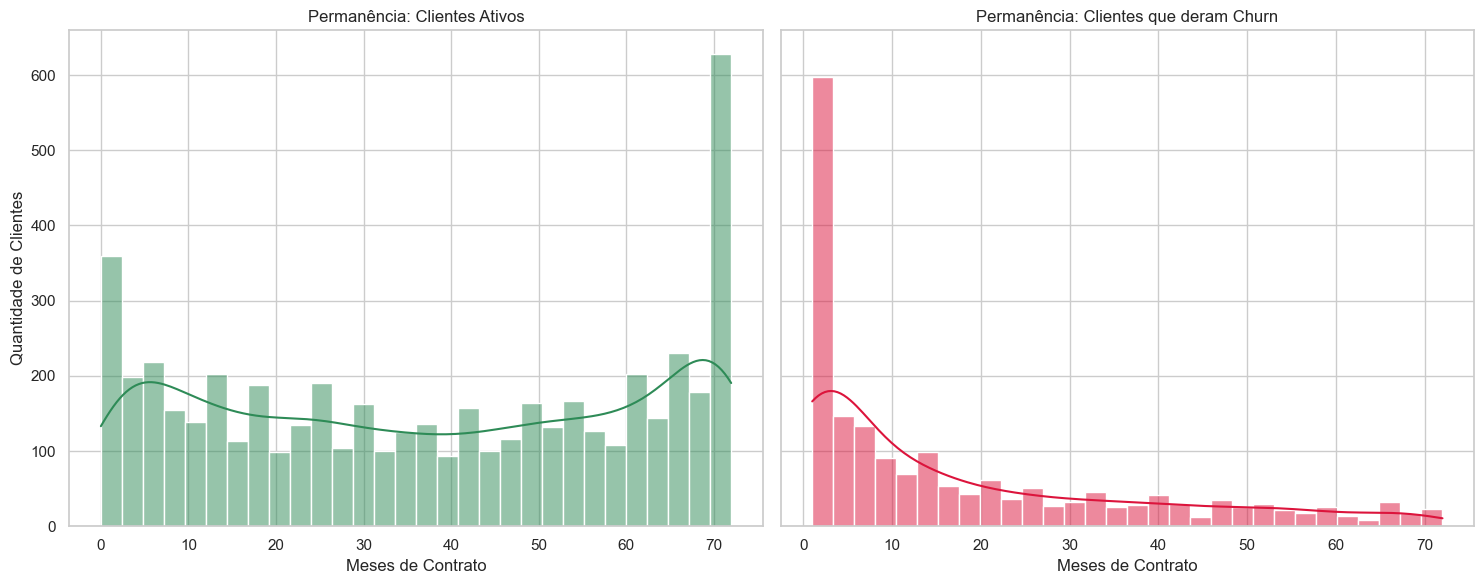

In [959]:
# tenure months: número de meses que o cliente está com a empresa

df_copy = df.copy()

# Criando a figura com 1 linha e 2 colunas, sharey=True para compartilhar o eixo y
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

# Gráfico 1: Clientes que NÃO cancelaram (Churn = 0)
sns.histplot(df_copy[df_copy['churn_value'] == 0]['tenure_months'], bins=30, kde=True, ax=axes[0], color='seagreen')
axes[0].set_title('Permanência: Clientes Ativos')
axes[0].set_xlabel('Meses de Contrato')
axes[0].set_ylabel('Quantidade de Clientes')

# Gráfico 2: Clientes que CANCELARAM (Churn = 1)
sns.histplot(df_copy[df_copy['churn_value'] == 1]['tenure_months'], bins=30, kde=True, ax=axes[1], color='crimson')
axes[1].set_title('Permanência: Clientes que deram Churn')
axes[1].set_xlabel('Meses de Contrato')

plt.tight_layout()
plt.show()

2 - Qual o tipo de contrato é o maior preditor? Clientes com contrato "Month-to-Month" (Mensal) saem significativamente mais do que aqueles com contratos de 1 ou 2 anos?

In [960]:
# verificar se existem valores nulos

df_copy = df.copy()
df['contract'].isnull().sum()

np.int64(0)

In [961]:
    # 1. Agrupamento para cálculo de taxa de churn
# O Churn Value (1=Saída, 0=Permanência) facilita a média
report = df_copy.groupby('contract')['churn_value'].agg(['count', 'mean']).rename(
        columns={'count': 'total_clientes', 'mean': 'taxa_churn'}
    )

# Transformando em porcentagem para o board executivo
report['taxa_churn'] = (report['taxa_churn'] * 100).round(2)

report.sort_values(by='taxa_churn', ascending=False)

,total_clientes,taxa_churn
contract,,
Month-to-month,3875,42.71
One year,1473,11.27
Two year,1695,2.83


3 - Clientes com contrato "Month-to-month" que não possuem suporte técnico têm uma propensão ao churn significativamente maior do que aqueles que possuem.

Taxa de Churn (%) por Contrato e Suporte Técnico:
tech_support           No  No internet service        Yes
contract                                                 
Month-to-month  50.373134            18.893130  30.700447
One year        14.721724             2.472527  13.586957
Two year         5.932203             0.783699   3.532278


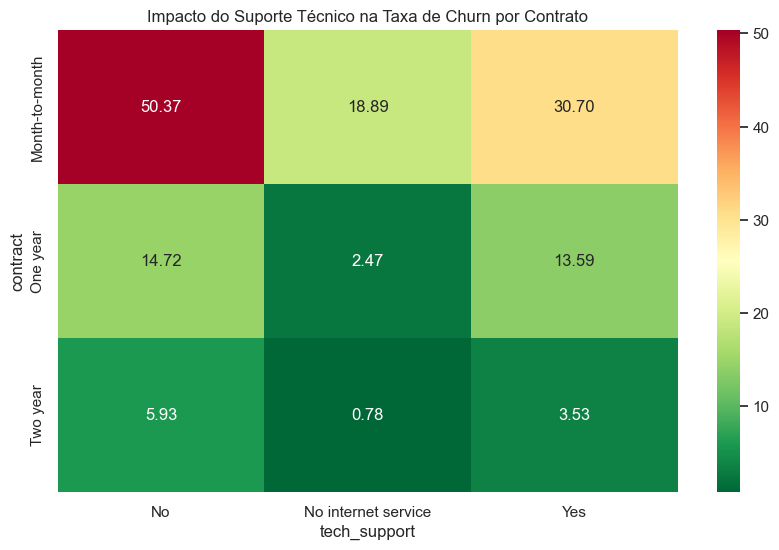

In [962]:
# Tabela de Contingência (Pivot Table).

df_copy = df.copy()

df_cruzado = df_copy.pivot_table(
        index='contract', 
        columns='tech_support', 
        values='churn_value', 
        aggfunc='mean'
    ) * 100
    
df_cruzado.round(2)

print("Taxa de Churn (%) por Contrato e Suporte Técnico:")
print(df_cruzado)

# Visualização recomendada: Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df_cruzado, annot=True, cmap='RdYlGn_r', fmt='.2f')
plt.title('Impacto do Suporte Técnico na Taxa de Churn por Contrato')
plt.show()

4 - Qual a taxa de Churn para cada modalidade de serviço?

In [963]:
df_copy = df.copy()

# Calcula a taxa de churn para todas as modalidades de serviço.
servicos = [
        'phone_service', 'multiple_lines', 'internet_service', 
        'online_security', 'online_backup', 'device_protection', 
        'tech_support', 'streaming_tv', 'streaming_movies'
    ]

taxas_servicos = {}

for servico in servicos:
        # Calculando a média de Churn Value por categoria do serviço
        taxa = df_copy.groupby(servico)['churn_value'].mean() * 100
        taxas_servicos[servico] = taxa.round(2)

print(taxas_servicos)

{'phone_service': phone_service
No     24.93
Yes    26.71
Name: churn_value, dtype: float64, 'multiple_lines': multiple_lines
No                  25.04
No phone service    24.93
Yes                 28.61
Name: churn_value, dtype: float64, 'internet_service': internet_service
DSL            18.96
Fiber optic    41.89
No              7.40
Name: churn_value, dtype: float64, 'online_security': online_security
No                     41.77
No internet service     7.40
Yes                    14.61
Name: churn_value, dtype: float64, 'online_backup': online_backup
No                     39.93
No internet service     7.40
Yes                    21.53
Name: churn_value, dtype: float64, 'device_protection': device_protection
No                     39.13
No internet service     7.40
Yes                    22.50
Name: churn_value, dtype: float64, 'tech_support': tech_support
No                     41.64
No internet service     7.40
Yes                    15.17
Name: churn_value, dtype: float64, 'str

**Análise de Churn por Modalidade de Serviço**

Esta tabela apresenta a taxa de evasão (churn) segmentada por serviço, auxiliando na identificação de pontos críticos e serviços que geram maior retenção de clientes.

| Modalidade de Serviço                |   Taxa de Churn (%) | Impacto na Retenção         |
|:-------------------------------------|--------------------:|:----------------------------|
| Internet (Fiber Optic)               |               41.89 | Crítico (Evasão muito alta) |
| Internet (DSL)                       |               18.96 | Moderado                    |
| Internet (Nenhuma)                   |                7.4  | Baixo (Fiel)                |
| Segurança Online (Não possui)        |               41.77 | Alto Risco                  |
| Segurança Online (Possui)            |               14.61 | Alta Retenção               |
| Suporte Técnico (Não possui)         |               41.64 | Alto Risco                  |
| Suporte Técnico (Possui)             |               15.17 | Alta Retenção               |
| Backup Online (Não possui)           |               39.93 | Moderado/Alto               |
| Backup Online (Possui)               |               21.53 | Moderado                    |
| Proteção de Dispositivo (Não possui) |               39.13 | Moderado/Alto               |
| Proteção de Dispositivo (Possui)     |               22.5  | Moderado                    |
| Streaming TV (Não possui)            |               33.52 | Baixo/Neutro                |
| Streaming TV (Possui)                |               30.07 | Baixo/Neutro                |
| Streaming Movies (Não possui)        |               33.68 | Baixo/Neutro                |
| Streaming Movies (Possui)            |               29.94 | Baixo/Neutro                |
| Telefonia (Sim)                      |               26.71 | Baixo                       |
| Telefonia (Não)                      |               24.93 | Baixo                       |

5 - Existe um "efeito ecossistema"? Clientes que assinam mais serviços adicionais (ex: Segurança + Backup + Suporte) tendem a ter um Churn menor do que aqueles que assinam apenas o serviço básico de Internet?

In [964]:
#Analisa o impacto do número de serviços adicionais assinados na taxa de churn de clientes que possuem internet

def analisar_efeito_ecossistema(df):
    # 1. Filtrar apenas clientes que possuem serviço de internet
    df_internet = df[df["internet_service"] != "No"].copy()

    # Listar os serviços de valor agregado (VAS) que compõem o ecossistema
    servicos_vas = [
        "online_security",
        "online_backup",
        "device_protection",
        "tech_support",
    ]

    # 2. Feature Engineering: Criar o score somando onde o cliente respondeu 'Yes'
    # Transformando o booleano (True/False) em inteiro (1/0) para somar
    df_internet["total_servicos_adicionais"] = (df_internet[servicos_vas] == "Yes").sum(axis=1)

    # 3. Agrupando para cálculo das métricas de negócio
    analise_ecossistema = (
        df_internet.groupby("total_servicos_adicionais")["churn_value"]
            .agg(["count", "mean"])
            .rename(columns={"count": "total_clientes", "mean": "taxa_churn"})
    )

    # Convertendo a taxa para formato percentual
    analise_ecossistema["taxa_churn"] = (analise_ecossistema["taxa_churn"] * 100).round(2)

    return analise_ecossistema

df_copy = df.copy()
df_resultado_ecossistema = analisar_efeito_ecossistema(df_copy)
print(df_resultado_ecossistema)

                           total_clientes  taxa_churn
total_servicos_adicionais                            
0                                    1267       56.67
1                                    1467       38.85
2                                    1372       23.76
3                                     941       12.43
4                                     470        5.32


Sim, há um impacto drástico e inversamente proporcional entre o número de serviços de valor agregado (VAS) assinados e a taxa de evasão. Clientes sem nenhum serviço adicional apresentam a maior taxa de churn do dataset (56,67%). Contudo, à medida que o cliente adota o ecossistema da operadora, a taxa de churn decresce acentuadamente para 38,85% (1 serviço), 23,76% (2 serviços), 12,43% (3 serviços) e atinge seu patamar mínimo de 5,32% quando todos os 4 serviços estão ativos.

6 - Quais são as combinações de serviços mais comuns entre os clientes que cancelaram?


In [965]:
df_copy = df.copy()

# Identifica as combinações de serviços mais comuns entre os clientes que cancelaram o contrato.
def encontrar_combos_churn(df):

    # 1. Filtrar apenas clientes que cancelaram (Churn Value == 1)
    df_churn = df[df["churn_value"] == 1].copy()

    # Listar os serviços que queremos analisar
    colunas_servicos = [
        "phone_service",
        "multiple_lines",
        "internet_service",
        "online_security",
        "online_backup",
        "device_protection",
        "tech_support",
        "streaming_tv",
        "streaming_movies",
    ]

    # 2. Criar uma representação textual do "combo" de cada cliente
    def construir_combo(row):
        servicos_ativos = []
        for col in colunas_servicos:
            # Se for internet, pegamos o tipo (Fiber, DSL)
            if col == "internet_service" and row[col] != "No":
                servicos_ativos.append(row[col])
            # Para os demais, se for 'Yes', adicionamos o nome do serviço
            elif row[col] == "Yes":
                servicos_ativos.append(col.replace("_", " ").title())

        # Se não tiver nenhum serviço ativo
        if not servicos_ativos:
            return "Nenhum serviço"

        # Retorna os serviços separados por ' + '
        return " + ".join(servicos_ativos)

    # Aplicando a função para mapear os combos
    df_churn["combo_servicos"] = df_churn.apply(construir_combo, axis=1)

    # 3. Contando e calculando a representação percentual dentro do churn
    analise_combos = (
        df_churn["combo_servicos"]
        .value_counts()
        .to_frame(name="total_cancelamentos")
    )

    total_churn = analise_combos["total_cancelamentos"].sum()
    analise_combos["percentual_do_churn (%)"] = (
        (analise_combos["total_cancelamentos"] / total_churn) * 100
    ).round(2)

    return analise_combos.head(10)  # Retorna os 10 combos mais comuns


# Executando a análise
df_top_combos_churn = encontrar_combos_churn(df_copy)
print(df_top_combos_churn)

                                                    total_cancelamentos  \
combo_servicos                                                            
Phone Service + Fiber optic                                         138   
Phone Service                                                       103   
Phone Service + Multiple Lines + Fiber optic                        103   
Phone Service + Multiple Lines + Fiber optic + ...                   73   
Phone Service + DSL                                                  70   
Phone Service + Multiple Lines + Fiber optic + ...                   61   
Phone Service + Multiple Lines + Fiber optic + ...                   58   
Phone Service + Multiple Lines + Fiber optic + ...                   56   
Phone Service + Fiber optic + Streaming Tv                           51   
Phone Service + Fiber optic + Streaming Tv + St...                   43   

                                                    percentual_do_churn (%)  
combo_servicos       

**Resposta**

A análise de co-ocorrência dos serviços entre os clientes evadidos (churn_value == 1) revela que o maior ofensor da base é a combinação de Phone Service + Fiber optic, responsável por 7,38% de todo o churn da companhia.

O segundo padrão mais crítico é composto por clientes que possuem apenas Phone Service (5,51%), seguido de perto por variantes que agregam múltiplas linhas à fibra óptica (Phone Service + Multiple Lines + Fiber optic, gerando mais 5,51% de evasão).

O padrão predominante no churn não é a telefonia isolada, mas sim a presença da Internet por Fibra Óptica combinada com a ausência de ecossistemas de proteção (como suporte técnico ou segurança). Clientes adquirem o pacote de ultravelocidade (Fibra) + Telefone e cancelam massivamente por falta de tração de serviços adicionais que gerem retenção.

8 - O "Ticket Médio" influencia? Clientes que pagam as contas mais altas (Monthly Charges) saem mais? Eles podem estar achando o serviço caro em comparação aos concorrentes.

SUMÁRIO ESTATÍSTICO DETALHADO: monthly_charges
count    7043.00
mean       64.76
std        30.09
min        18.25
25%        35.50
50%        70.35
75%        89.85
max       118.75



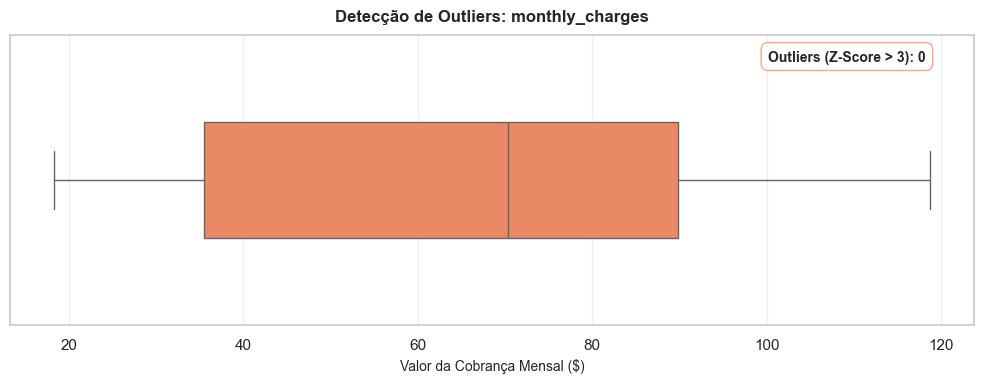

In [966]:
# Entendendo a distribuição do valor da cobrança mensal (Monthly Charges)
# Gera um relatório estatístico e plota a distribuição das cobranças mensais segregadas por Churn.

df_copy = df.copy()

def auditar_outliers_monthly_charges(df):
    coluna = 'monthly_charges'
    
    # Limpeza dos dados: Remover valores nulos para evitar distorções na análise
    dados_limpos = df[coluna].dropna()

    dados_limpos = dados_limpos.str.replace(',', '.').astype(float)

    print("=" * 50)
    print(f"SUMÁRIO ESTATÍSTICO DETALHADO: {coluna}")
    print("=" * 50)
    # O .to_string() garante que o pandas force a impressão de todas as linhas do describe
    print(dados_limpos.describe().round(2).to_string())
    print("=" * 50 + "\n")
    
    # Configuração da figura (1 linha, 1 coluna)
    fig, ax = plt.subplots(figsize=(10, 4))
    
    # Plotagem do Boxplot
    sns.boxplot(x=dados_limpos, ax=ax, color='coral', width=0.4)
    
    # Configuração de rótulos e títulos claros
    ax.set_title(f'Detecção de Outliers: {coluna}', fontweight='bold', fontsize=12, pad=10)
    ax.set_xlabel('Valor da Cobrança Mensal ($)', fontsize=10)
    ax.grid(axis='x', alpha=0.3)
    
    # Cálculo Estatístico do Z-Score para detecção de outliers
    # O Z-Score mede quantos desvios padrões o dado está afastado da média
    z_scores = np.abs(stats.zscore(dados_limpos))
    outlier_count = (z_scores > 3).sum()
    
    # Inserção do rótulo de contagem no canto superior direito do gráfico
    ax.text(
        0.95, 0.95, f'Outliers (Z-Score > 3): {outlier_count}', 
        transform=ax.transAxes, fontsize=10, fontweight='bold',
        verticalalignment='top', horizontalalignment='right',
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='coral', boxstyle='round,pad=0.5')
    )
    
    plt.tight_layout()
    plt.show()
    

# Executando o diagnóstico no seu DataFrame de normalizados
df_copy
auditar_outliers_monthly_charges(df_copy)



In [967]:
# Cruza as cobranças mensais com o status de Churn para validar se clientes com contas mais altas apresentam maior evasão.
df_copy = df.copy()
def analisar_influencia_ticket(df_analise):
    
    col_charges = "monthly_charges"
    col_churn = "churn_value"

    # Garantir que a coluna está no formato numérico correto (saneamento)
    df_analise[col_charges] = df_analise[col_charges].str.replace(',', '.').astype(float)
    df_analise = df_analise.dropna(subset=[col_charges])

    # Calcular as métricas globais de Ticket Médio por Grupo de Churn
    print("=" * 60)
    print("MÉTRICAS FINANCEIRAS POR GRUPO (TICKET MÉDIO)")
    print("=" * 60)

    # Agrupa por churn e calcula média e mediana do valor mensal
    metricas_grupo = df_analise.groupby("churn_value")[col_charges].agg(
        ["count", "mean", "median"]
    )
    metricas_grupo.columns = [
        "Total Clientes",
        "Ticket Médio (Média)",
        "Mediana de Gastos",
    ]
    print(metricas_grupo.round(2).to_string())
    print("-" * 60)

    # 3. Criar Faixas de Preço Dinâmicas baseadas nos Quartis da Base
    # Usamos os limites exatos do describe: min, 25%, 50%, 75% e max
    quartis = [
        df_analise[col_charges].min() - 1,
        35.50,
        70.35,
        89.85,
        df_analise[col_charges].max() + 1,
    ]
    labels_faixas = [
        "Até $35.50 (Econômico)",
        "$35.50 a $70.35 (Standard)",
        "$70.35 a $89.85 (Premium)",
        "Acima de $89.85 (Ultra)",
    ]

    df_analise["faixa_ticket"] = pd.cut(
        df_analise[col_charges], bins=quartis, labels=labels_faixas
    )

    # 4. Calcular a Taxa de Churn real para cada Faixa de Preço
    print("\n" + "=" * 60)
    print("TAXA DE CHURN POR FAIXA DE TICKET MENSAL")
    print("=" * 60)

    analise_faixas = (
        df_analise.groupby("faixa_ticket")[col_churn]
        .agg(["count", "mean"])
        .rename(columns={"count": "Total na Faixa", "mean": "Taxa de Churn"})
    )

    # Converte a taxa média em porcentagem
    analise_faixas["Taxa de Churn (%)"] = (
        analise_faixas["Taxa de Churn"] * 100
    ).round(2)
    print(analise_faixas[["Total na Faixa", "Taxa de Churn (%)"]].to_string())
    print("=" * 60)


# Executando a análise final de negócio
analisar_influencia_ticket(df_copy)

MÉTRICAS FINANCEIRAS POR GRUPO (TICKET MÉDIO)
             Total Clientes  Ticket Médio (Média)  Mediana de Gastos
churn_value                                                         
0                      5174                 61.27              64.43
1                      1869                 74.44              79.65
------------------------------------------------------------

TAXA DE CHURN POR FAIXA DE TICKET MENSAL
                            Total na Faixa  Taxa de Churn (%)
faixa_ticket                                                 
Até $35.50 (Econômico)                1762              11.24
$35.50 a $70.35 (Standard)            1766              24.58
$70.35 a $89.85 (Premium)             1757              37.51
Acima de $89.85 (Ultra)               1758              32.88


/var/folders/44/nj31f6_s2ls3lmk6mzlqssbc0000gn/T/ipykernel_925/1810296728.py:55: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_analise.groupby("faixa_ticket")[col_churn]


**Respostas**

Sim, o valor da cobrança mensal é um forte preditor de evasão. Os dados provam que o Ticket Médio dos clientes evadidos ($74.44) é expressivamente superior ao dos clientes retidos ($61.27).

Ao segmentar a base em volumes iguais através de quartis, observamos que a insatisfação com o preço ou a falta de percepção de valor escala junto com a fatura: a Taxa de Churn salta de meros 11.24% na faixa Econômica para um pico alarmante de 37.51% na faixa Premium.

O cliente que paga mais caro está quebrando o contrato massivamente. O leve recuo na faixa Ultra (32.88%) sugere que os clientes de altíssimo valor possuem alguma amarra técnica a mais, porém a zona de perigo real está concentrada a partir dos $70.00 mensais, o que corrobora a hipótese de que o preço alto estimula o cliente a buscar ofertas concorrentes.

9 - Existe correlação entre o Método de Pagamento e o Churn? Clientes que pagam com "Mailed Check" (Cheque/Boleto manual) saem mais do que quem usa débito automático? (Geralmente, o atrito no pagamento gera churn).

In [968]:
# Analisa a correlação entre os diferentes métodos de pagament e a taxa de churn na base de clientes.

df_copy = df.copy()

def analisar_impacto_pagamento(df_analise):

    col_churn = "churn_value"
    col_pagamento = "payment_method"

    print("=" * 65)
    print("ANÁLISE DE CHURN POR MÉTODO DE PAGAMENTO")
    print("=" * 65)

    # Agrupamento para cálculo das volumetrias e taxas
    total_por_metodo = (
        df_analise.groupby(col_pagamento)[col_churn]
        .count()
        .to_frame(name="Total Clientes")
    )

    # Tratamento para garantir o cálculo da taxa média
    taxa_churn = df_analise.groupby(col_pagamento)[col_churn].mean()

    # Adicionando os percentuais ao relatório final
    total_por_metodo["Taxa de Churn (%)"] = (taxa_churn * 100).round(2)

    # Ordena da maior taxa de churn para a menor
    total_por_metodo = total_por_metodo.sort_values(
        by="Taxa de Churn (%)", ascending=False
    )

    print(total_por_metodo.to_string())
    print("=" * 65)


# Executando a análise
analisar_impacto_pagamento(df_copy)

ANÁLISE DE CHURN POR MÉTODO DE PAGAMENTO
                           Total Clientes  Taxa de Churn (%)
payment_method                                              
Electronic check                     2365              45.29
Mailed check                         1612              19.11
Bank transfer (automatic)            1544              16.71
Credit card (automatic)              1522              15.24


**Resposta**

Sim, há uma correlação explícita e estatisticamente significativa entre a forma de pagamento escolhida e a propensão ao cancelamento.

Validando parcialmente a hipótese inicial, os clientes que utilizam o método físico Mailed Check apresentam uma taxa de evasão de 19,11%, um índice superior aos métodos automatizados como Bank Transfer (16,71%) e Credit Card (15,24%).

Contudo, o grande e alarmante vilão da base é o Electronic Check, que registra uma taxa de churn avassaladora de 45,29%.

Métodos que exigem uma tomada de decisão e ação proativa do cliente todo mês para quitar a fatura (como abrir um e-mail, copiar o código de barras de um boleto digital/Electronic Check ou preencher um cheque/Mailed Check) geram fricção recorrente. O cliente é forçado a reavaliar mensalmente o valor do serviço. A recomendação estratégica para o CRM é criar incentivos financeiros (como descontos na primeira fatura) para migrar agressivamente os clientes de canais de 'cheque/boleto' para a recorrência automática.

10 - Idosos se comportam de forma diferente? Eles usam menos serviços de streaming, mas talvez valorizem mais a estabilidade do telefone fixo.

- A Taxa de Churn: Idosos cancelam mais ou menos do que os mais jovens?
- Adoção de Telefonia Fixo: Eles realmente possuem mais Phone Service ou Multiple Lines?
- Adoção de Streaming: Eles consomem menos Streaming TV e Streaming Movies?

In [969]:
# Realiza uma análise comparativa do comportamento de consumo e taxa de evasão (Churn) entre clientes idosos e não-idosos.
df_copy = df.copy()

def analisar_comportamento_seniors(df_analise):

    col_senior = "senior_citizen"
    col_churn = "churn_value"

    print("=" * 65)
    print("MIGRANDO ANÁLISE: IDOSOS VS NÃO-IDOSOS")
    print("=" * 65)

    # Mapeando os rótulos de Idoso para ficar visualmente limpo no relatório
    df_analise["Perfil Idoso"] = df_analise[col_senior].map(
        {1: "Sim (Senior)", 0: "Não (Jovem/Adulto)", "Yes": "Sim (Senior)", "No": "Não (Jovem/Adulto)"}
    )

    # 2. Taxa de Churn por Faixa Etária
    perfil_churn = (
        df_analise.groupby("Perfil Idoso")[col_churn]
        .agg(["count", "mean"])
        .rename(columns={"count": "Total Clientes", "mean": "Taxa de Churn"})
    )
    perfil_churn["Taxa de Churn (%)"] = (
        perfil_churn["Taxa de Churn"] * 100
    ).round(2)

    print("1. PROPORÇÃO DA BASE E TAXA DE CHURN:")
    print(perfil_churn[["Total Clientes", "Taxa de Churn (%)"]].to_string())
    print("-" * 65)

    # Análise 2: Adoção de Serviços (Telefone e Streamings)
    # Procurando as colunas de serviço na base de dados
    servicos_interesse = {
        "Telefone Fixo": ["phone_service", "PhoneService"],
        "Streaming TV": ["streaming_tv", "StreamingTV"],
        "Streaming Filmes": ["streaming_movies", "StreamingMovies"],
    }

    print("2. TAXA DE ADOÇÃO DE PRODUTOS (% DE ADERÊNCIA DE CADA GRUPO):")

    for nome_amigavel, opcoes in servicos_interesse.items():
        col_encontrada = None
        for opcao in opcoes:
            if opcao in df_analise.columns:
                col_encontrada = opcao
                break

        if col_encontrada:
            # Cria uma flag booleana se o cliente tem o serviço ativo (ignorando 'No phone service' ou 'No internet')
            df_analise["possui_servico"] = df_analise[col_encontrada].map(
                lambda x: 1 if str(x).lower() == "yes" or x == 1 else 0
            )

            # Calcula o percentual de adoção do serviço dentro de cada grupo etário
            adocao = (
                df_analise.groupby("Perfil Idoso")["possui_servico"].mean()
                * 100
            ).round(2)
            print(f"\nAdoção de {nome_amigavel}:")
            print(adocao.to_string())
        else:
            print(f"\n[Aviso] Não encontrei a coluna para: {nome_amigavel}")

    print("=" * 65)


# Executando o diagnóstico etário
analisar_comportamento_seniors(df_copy)

MIGRANDO ANÁLISE: IDOSOS VS NÃO-IDOSOS
1. PROPORÇÃO DA BASE E TAXA DE CHURN:
                    Total Clientes  Taxa de Churn (%)
Perfil Idoso                                         
Não (Jovem/Adulto)            5901              23.61
Sim (Senior)                  1142              41.68
-----------------------------------------------------------------
2. TAXA DE ADOÇÃO DE PRODUTOS (% DE ADERÊNCIA DE CADA GRUPO):

Adoção de Telefone Fixo:
Perfil Idoso
Não (Jovem/Adulto)    90.21
Sim (Senior)          90.89

Adoção de Streaming TV:
Perfil Idoso
Não (Jovem/Adulto)    36.18
Sim (Senior)          50.09

Adoção de Streaming Filmes:
Perfil Idoso
Não (Jovem/Adulto)    36.21
Sim (Senior)          52.10


**Resposta**

A análise demográfica e de portfólio revela que o público idoso (Senior Citizen) se comporta de forma muito diferente do esperado, quebrando mitos tradicionais de mercado.

Quanto ao consumo, a hipótese de que idosos rejeitam serviços modernos de entretenimento foi estatisticamente refutada: a taxa de adoção de Streaming TV (50,09%) e Streaming Filmes (52,10%) entre os idosos é significativamente superior à do público mais jovem (~36%). A preferência por telefonia fixa é alta e equivalente em ambos os grupos (~90%).

Contudo, o dado mais crítico reside na retenção: os idosos registram uma Taxa de Churn avassaladora de 41,68%, contra 23,61% dos não-idosos.

O público sênior nesta base é altamente tecnológico e consome pacotes robustos de entretenimento. Porém, eles evadem em um ritmo alarmante. O alto churn não é por falta de interesse nos serviços, mas provavelmente por atritos na experiência de uso (UX), como dificuldades com interfaces de streaming complexas, falta de suporte técnico especializado para configuração dos aparelhos ou problemas com métodos manuais de cobrança (visto que o boleto/cheque eletrônico é o maior vilão da base).

11 - Dependentes e Parceiros: Clientes com famílias (parceiros e dependentes) tendem a ser mais estáveis (menor churn) do que clientes solteiros?

- A visão isolada: Qual é a taxa de churn de quem tem parceiro e de quem tem dependentes?
- A visão combinada (A estrutura familiar real): Qual é o churn do cliente "Totalmente Solteiro" (sem parceiro e sem dependente) versus o cliente "Chefe de Família" (com parceiro e dependentes)?

In [970]:
# Analisa o impacto de ter parceiros e dependentes na estabilidade do cliente (taxa de churn)

df_copy = df.copy()

def analisar_impacto_familiar(df_analise):

    col_churn = 'churn_value'
    col_partner = 'partner'
    col_dependents = 'dependents'

    print("=" * 65)
    print("ANÁLISE DE IMPACTO FAMILIAR NO CHURN")
    print("=" * 65)

    # Análise Isolada: Parceiros
    churn_parceiro = (
        df_analise.groupby(col_partner)[col_churn].mean() * 100
    ).round(2)
    print("1. TAXA DE CHURN ISOLADA - POSSUI PARCEIRO(A)?")
    print(churn_parceiro.to_string())
    print("-" * 65)

    # Análise Isolada: Dependentes
    churn_dependente = (
        df_analise.groupby(col_dependents)[col_churn].mean() * 100
    ).round(2)
    print("2. TAXA DE CHURN ISOLADA - POSSUI DEPENDENTES (FILHOS/PAIS)?")
    print(churn_dependente.to_string())
    print("-" * 65)

    # Combinando as duas para ver a estrutura familiar real
    # Criamos 4 perfis: Solteiro Absoluto, Apenas Parceiro, Apenas Dependentes, Família Completa
    def rotular_familia(row):
        p = str(row[col_partner]).strip().lower()
        d = str(row[col_dependents]).strip().lower()

        tem_p = p in ["yes", "1", "true"]
        tem_d = d in ["yes", "1", "true"]

        if not tem_p and not tem_d:
            return "Solteiro Absoluto (Sem Parceiro / Sem Dep)"
        elif tem_p and not tem_d:
            return "Casal Sem Filhos (Com Parceiro / Sem Dep)"
        elif not tem_p and tem_d:
            return "Monoparental (Sem Parceiro / Com Dep)"
        else:
            return "Família Completa (Com Parceiro / Com Dep)"

    df_analise["estrutura_familiar"] = df_analise.apply(rotular_familia, axis=1)

    # Relatório Consolidado da Estrutura Familiar
    relatorio_familia = (
        df_analise.groupby("estrutura_familiar")[col_churn]
        .agg(["count", "mean"])
        .rename(columns={"count": "Total Clientes", "mean": "Taxa de Churn"})
    )
    relatorio_familia["Taxa de Churn (%)"] = (
        relatorio_familia["Taxa de Churn"] * 100
    ).round(2)

    print("3. TAXA DE CHURN POR ESTRUTURA FAMILIAR COMBINADA:")
    print(
        relatorio_familia.sort_values(
            by="Taxa de Churn (%)", ascending=False
        )[["Total Clientes", "Taxa de Churn (%)"]].to_string()
    )
    print("=" * 65)


# Executando o diagnóstico familiar
analisar_impacto_familiar(df_copy)

ANÁLISE DE IMPACTO FAMILIAR NO CHURN
1. TAXA DE CHURN ISOLADA - POSSUI PARCEIRO(A)?
partner
No     32.96
Yes    19.66
-----------------------------------------------------------------
2. TAXA DE CHURN ISOLADA - POSSUI DEPENDENTES (FILHOS/PAIS)?
dependents
No     32.55
Yes     6.52
-----------------------------------------------------------------
3. TAXA DE CHURN POR ESTRUTURA FAMILIAR COMBINADA:
                                            Total Clientes  Taxa de Churn (%)
estrutura_familiar                                                           
Solteiro Absoluto (Sem Parceiro / Sem Dep)            3339              34.44
Casal Sem Filhos (Com Parceiro / Sem Dep)             2077              29.51
Monoparental (Sem Parceiro / Com Dep)                  302              16.56
Família Completa (Com Parceiro / Com Dep)             1325               4.23


**Resposta**

Sim, a hipótese de que a estrutura familiar funciona como um fator de estabilização do cliente é totalmente verdadeira e comprovada pelos dados. Há uma correlação inversa perfeita entre a complexidade do núcleo familiar do cliente e a sua propensão ao Churn.

O perfil classificado como Solteiro Absoluto (Sem Parceiro e Sem Dependentes) é o maior ofensor de evasão da base, registrando uma taxa de churn de 34,44%. Em contrapartida, à medida que adicionamos membros à residência, o risco despenca: a taxa cai para 29,51% em casais sem filhos, vai para 16,56% em lares monoparentais e atinge a estabilidade máxima de 4,23% no grupo Família Completa (Com Parceiro e Com Dependentes).

A presença de dependentes na casa atua como uma 'âncora operacional'. O custo de mudança (o incômodo de agendar novas instalações e o risco de interrupção do serviço afetando rotinas de estudo ou trabalho de terceiros) cria uma barreira psicológica massiva contra o cancelamento. Estratégias de retenção e cross-sell devem priorizar a oferta de planos familiares, agregando benefícios para múltiplos membros da casa para transformar voluntariamente clientes solteiros de alto risco em contas familiares blindadas.

12 - Quais são os principais "Churn Reasons"? Olhando apenas para quem já saiu, quais as reclamações mais comuns?

In [971]:
# Filtra a base para clientes que deram churn e rankeia os principais motivos declarados (Churn Reasons) para guiar o negócio e o Feature Engineering.

df_copy = df.copy()

def analisar_motivos_churn(df_analise):
    col_churn = 'churn_value'
    col_reason = 'churn_reason'
    
    print("=" * 70)
    print("RANKING DOS PRINCIPAIS 'CHURN REASONS' (APENAS QUEM JÁ SAIU)")
    print("=" * 70)

    # Filtrando estritamente os clientes que deram churn
    # O filtro aceita tanto o formato numérico 1 quanto o texto 'Yes'
    df_evadidos = df_analise[df_analise[col_churn] == 1]

    #Contagem absoluta e percentual dos motivos declarados
    ranking_motivos = (
        df_evadidos[col_reason]
        .value_counts()
        .to_frame(name="Quantidade de Clientes")
    )
    ranking_motivos["Representatividade (%)"] = (
        (ranking_motivos["Quantidade de Clientes"] / len(df_evadidos)) * 100
    ).round(2)

    # Exibindo o Top 15 motivos mais comuns
    print(ranking_motivos.head(15).to_string())
    print("=" * 70)


# Executando a auditoria de motivos
analisar_motivos_churn(df_copy)

RANKING DOS PRINCIPAIS 'CHURN REASONS' (APENAS QUEM JÁ SAIU)
                                           Quantidade de Clientes  Representatividade (%)
churn_reason                                                                             
Attitude of support person                                    192                   10.27
Competitor offered higher download speeds                     189                   10.11
Competitor offered more data                                  162                    8.67
Don't know                                                    154                    8.24
Competitor made better offer                                  140                    7.49
Attitude of service provider                                  135                    7.22
Competitor had better devices                                 130                    6.96
Network reliability                                           103                    5.51
Product dissatisfaction                

**Resposta**

A análise descritiva dos motivos de cancelamento (Churn Reasons) traz o diagnóstico definitivo sobre a dor do cliente. O principal ofensor isolado da base é o fator humano: 'Attitude of support person' lidera com 10,27% das ocorrências, indicando falhas severas no atendimento e suporte ao cliente.

No entanto, ao agrupar os motivos por categorias de negócio, a pressão da concorrência desponta como a principal força de evasão, acumulando mais de 33% dos cancelamentos através de ofertas de maior velocidade de download, mais pacotes de dados e aparelhos melhores. Reclamações explícitas de preço (Price too high) respondem por apenas 5,24%, provando que o cliente não sai simplesmente porque o serviço é caro, mas sim porque o concorrente entrega mais valor ou porque o atendimento interno é deficiente.

# Analisando com mais detalhe os dados do dataset

## Classificando nossas variáveis em tipo estatístico

### Qualitativa nominal
- Country
- State
- City
- Gender
- Payment Method (Categórico: Débito, Cartão, Cheque)

### Qualitativa nominal - categórica binária
- Senior Citizen
- Partner
- Dependents
- Phone Service
- Multiple Lines
- Internet Service
- Online Security
- Online Backup
- Device Protection
- Tech Support
- Streaming TV
- Streaming Movies
- Paperless Billing
- Churn Value

### Qualitativa ordinal
- Contract

### Quantitativa discreta
- Churn Score
- Tenure Months
- CLTV

### Quantitativa contínua
- Monthly Charge
- Total Charges

## Variáveis que deverão ser removidas

- Count
- CustomerID
- Lat Long
- Latitude
- Longitude
- Zip Code
- Churn Label
- Churn Reason

In [ ]:
colunas_a_remover = ['customerid', 'lat_long', 'latitude', 'longitude', 'count', 'zip_code', 'churn_score', 'churn_reason', 'churn_label']
df_base = df_copy.drop(columns=colunas_a_remover, errors='ignore')

print(f"Shape dos dados: {df.shape}")
print(f"\nPrimeiras linhas do dataset:")
df.head(10)

Shape dos dados: (7043, 33)

Primeiras linhas do dataset:


,customerid,count,country,state,city,zip_code,lat_long,latitude,longitude,gender,...,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn_label,churn_value,churn_score,cltv,churn_reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783","33,964131","-118,272783",Male,...,Month-to-month,Yes,Mailed check,"53,85","108,15",Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742","34,059281","-118,307420",Female,...,Month-to-month,Yes,Electronic check,"70,7","151,65",Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953","34,048013","-118,293953",Female,...,Month-to-month,Yes,Electronic check,"99,65","820,5",Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709","34,062125","-118,315709",Female,...,Month-to-month,Yes,Electronic check,"104,8","3046,05",Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293","34,039224","-118,266293",Male,...,Month-to-month,Yes,Bank transfer (automatic),"103,7","5036,3",Yes,1,89,5340,Competitor had better devices
5,4190-MFLUW,1,United States,California,Los Angeles,90020,"34.066367, -118.309868","34,066367","-118,309868",Female,...,Month-to-month,No,Credit card (automatic),"55,2","528,35",Yes,1,78,5925,Competitor offered higher download speeds
6,8779-QRDMV,1,United States,California,Los Angeles,90022,"34.02381, -118.156582","34,023810","-118,156582",Male,...,Month-to-month,Yes,Electronic check,"39,65","39,65",Yes,1,100,5433,Competitor offered more data
7,1066-JKSGK,1,United States,California,Los Angeles,90024,"34.066303, -118.435479","34,066303","-118,435479",Male,...,Month-to-month,No,Mailed check,"20,15","20,15",Yes,1,92,4832,Competitor made better offer
8,6467-CHFZW,1,United States,California,Los Angeles,90028,"34.099869, -118.326843","34,099869","-118,326843",Male,...,Month-to-month,Yes,Electronic check,"99,35","4749,15",Yes,1,77,5789,Competitor had better devices
9,8665-UTDHZ,1,United States,California,Los Angeles,90029,"34.089953, -118.294824","34,089953","-118,294824",Male,...,Month-to-month,No,Electronic check,"30,2","30,2",Yes,1,97,2915,Competitor had better devices


In [973]:
# Informações gerais sobre o dataset
print("=== INFORMAÇÕES DATASET APOS LIMPEZA ===\n")
print(df_base.info())

print("\n=== ESTATÍSTICAS DESCRITIVAS ===\n")
df_base.describe()

=== INFORMAÇÕES DATASET APOS LIMPEZA ===

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   country            7043 non-null   object
 1   state              7043 non-null   object
 2   city               7043 non-null   object
 3   gender             7043 non-null   object
 4   senior_citizen     7043 non-null   object
 5   partner            7043 non-null   object
 6   dependents         7043 non-null   object
 7   tenure_months      7043 non-null   int64 
 8   phone_service      7043 non-null   object
 9   multiple_lines     7043 non-null   object
 10  internet_service   7043 non-null   object
 11  online_security    7043 non-null   object
 12  online_backup      7043 non-null   object
 13  device_protection  7043 non-null   object
 14  tech_support       7043 non-null   object
 15  streaming_tv       7043 non-null   object
 16  

,tenure_months,churn_value,cltv
count,7043.000000,7043.000000,7043.000000
mean,32.371149,0.265370,4400.295755
std,24.559481,0.441561,1183.057152
min,0.000000,0.000000,2003.000000
25%,9.000000,0.000000,3469.000000
50%,29.000000,0.000000,4527.000000
75%,55.000000,1.000000,5380.500000
max,72.000000,1.000000,6500.000000


## Ajustando tipo de dados

- monthly_charges, total_charges estão sendo interpretados como object, mas deveiram ser tratados como float

In [974]:
df_base = df_base.copy()

colunas_numericas = ['monthly_charges', 'total_charges']

# Convertendo e forçando erros a virarem NaN
for col in colunas_numericas:
    df_base[col] = df_base[col].astype(str).str.replace(',', '.', regex=False)
    df_base[col] = pd.to_numeric(df_base[col], errors='coerce')

df_base[colunas_numericas].head()

,monthly_charges,total_charges
0,53.85,108.15
1,70.70,151.65
2,99.65,820.50
3,104.80,3046.05
4,103.70,5036.30


## Análise de Missing Values

In [975]:
print("=== INFORMAÇÕES DE VALORES NULOS ===\n")
print(df_base.isnull().sum())

=== INFORMAÇÕES DE VALORES NULOS ===

country               0
state                 0
city                  0
gender                0
senior_citizen        0
partner               0
dependents            0
tenure_months         0
phone_service         0
multiple_lines        0
internet_service      0
online_security       0
online_backup         0
device_protection     0
tech_support          0
streaming_tv          0
streaming_movies      0
contract              0
paperless_billing     0
payment_method        0
monthly_charges       0
total_charges        11
churn_value           0
cltv                  0
dtype: int64


*** Após transformar o total_charges em float, aparecem 11 valores nulos na coluna

In [976]:
# Analisando se os valores já eram nulos antes da transformação ou se foram causados por erros de formatação

indices_nulos = df_base[df_base['total_charges'].isna()].index
print(indices_nulos)

valores_originais = df.loc[indices_nulos, ['tenure_months', 'monthly_charges', 'total_charges']]
print(valores_originais)

Index([2234, 2438, 2568, 2667, 2856, 4331, 4687, 5104, 5719, 6772, 6840], dtype='int64')
      tenure_months monthly_charges total_charges
2234              0           52,55              
2438              0           20,25              
2568              0           80,85              
2667              0           25,75              
2856              0           56,05              
4331              0           19,85              
4687              0           25,35              
5104              0              20              
5719              0            19,7              
6772              0           73,35              
6840              0            61,9              


*** Os valores nulos do total_charges é referente a clientes novos que não completaram 1 mês, desta forma, o total_charges será igual a 0

In [977]:
df_base['total_charges'] = df_base['total_charges'].fillna(0.0)

print("=== INFORMAÇÕES DE VALORES NULOS ===\n")
print(df_base.isnull().sum())

=== INFORMAÇÕES DE VALORES NULOS ===

country              0
state                0
city                 0
gender               0
senior_citizen       0
partner              0
dependents           0
tenure_months        0
phone_service        0
multiple_lines       0
internet_service     0
online_security      0
online_backup        0
device_protection    0
tech_support         0
streaming_tv         0
streaming_movies     0
contract             0
paperless_billing    0
payment_method       0
monthly_charges      0
total_charges        0
churn_value          0
cltv                 0
dtype: int64


## Análise da Variável Target (Churn Value)

=== DISTRIBUIÇÃO DA VARIÁVEL TARGET ===



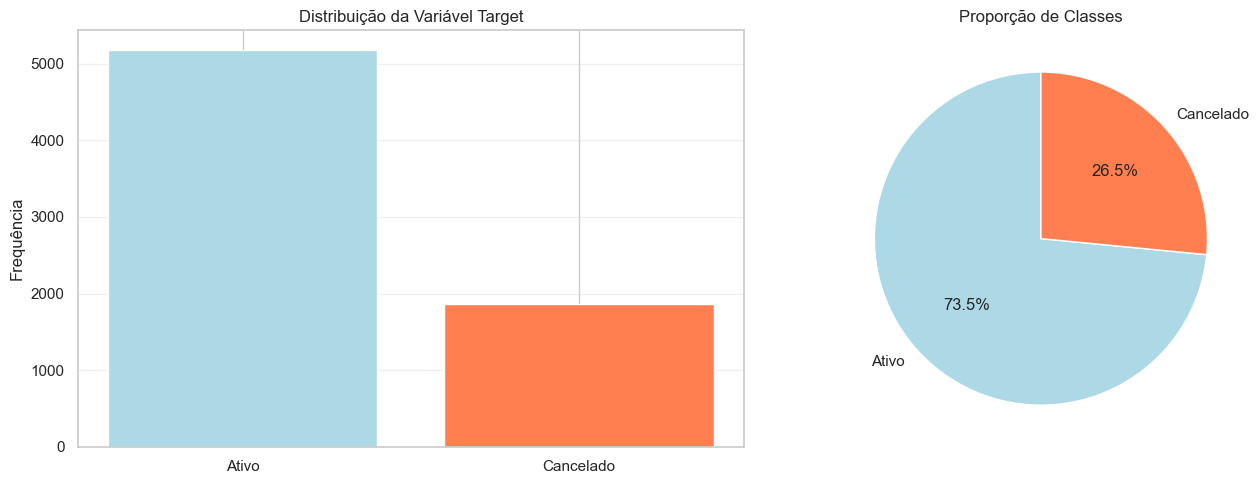


Ratio de balanceamento: 0.36
Dataset desbalanceado!


In [978]:
df_copy = df_base.copy()

print("=== DISTRIBUIÇÃO DA VARIÁVEL TARGET ===\n")
target_counts = df_copy['churn_value'].value_counts()
target_percentages = df_copy['churn_value'].value_counts(normalize=True) * 100

# Visualização
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de barras
axes[0].bar(['Ativo', 'Cancelado'], target_counts.values, color=['lightblue', 'coral'])
axes[0].set_ylabel('Frequência')
axes[0].set_title('Distribuição da Variável Target')
axes[0].grid(axis='y', alpha=0.3)

# Gráfico de pizza
axes[1].pie(target_counts.values, labels=['Ativo', 'Cancelado'], 
            autopct='%1.1f%%', colors=['lightblue', 'coral'], startangle=90)
axes[1].set_title('Proporção de Classes')

plt.tight_layout()
plt.show()

# Verificar se há desbalanceamento
ratio = target_counts.min() / target_counts.max()
print(f"\nRatio de balanceamento: {ratio:.2f}")
if ratio < 0.5:
    print("Dataset desbalanceado!")
else:
    print("✓ Dataset razoavelmente balanceado.")

## Análise de Outliers

**Z-Score**: Identifica valores que estão a mais de 3 desvios padrão da média

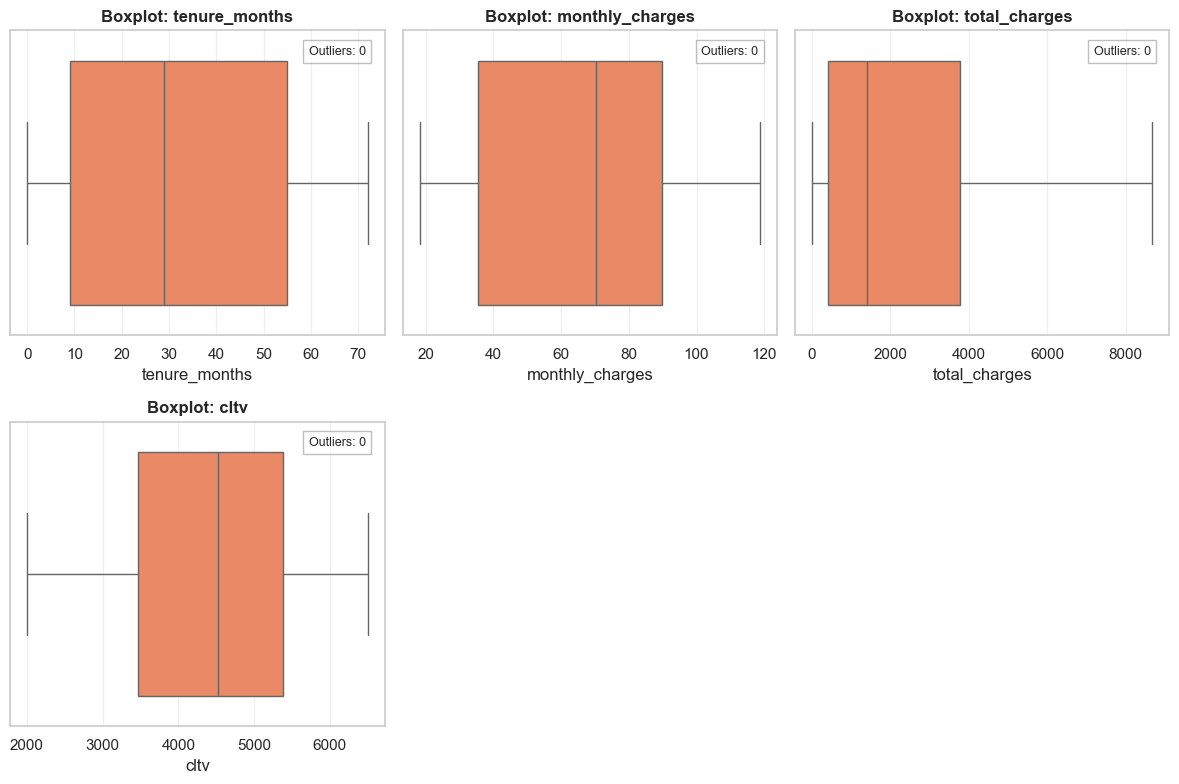

In [979]:
df_copy = df_base.copy()

numeric_cols = df_copy.select_dtypes(include=[np.number]).columns

# Exclui a variável target
numeric_cols = numeric_cols.drop(['churn_value'], errors='ignore')  

n = len(numeric_cols)
ncols = 3
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(12, 4 * nrows))
axes = axes.ravel()

for idx, col in enumerate(numeric_cols):
    sns.boxplot(x=df_copy[col], ax=axes[idx], color='coral')
    axes[idx].set_title(f'Boxplot: {col}', fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].grid(axis='x', alpha=0.3)
    col_zscore = np.abs(stats.zscore(df_copy[col].dropna()))
    outlier_count = (col_zscore > 3).sum()
    axes[idx].text(0.95, 0.95, f'Outliers: {outlier_count}', 
                   transform=axes[idx].transAxes, fontsize=9,
                   verticalalignment='top', horizontalalignment='right',
                   bbox=dict(facecolor='white', alpha=0.5, edgecolor='gray'))

for ax in axes[n:]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

**Boxplot total_charges**

- Mediana Deslocada para a Esquerda: A linha central dentro da caixa laranja (a mediana, ou Q2) está muito próxima de R$ 1.500. Isso significa que $50\%$ da sua base de clientes gastou, no total acumulado, menos de R$ 1.500.

- Cauda Longa para a Direita (Assimetria Positiva / Right-Skewed): A distância entre o terceiro quartil (Q3, o fim da caixa) e o valor máximo (a linha do "bigode" direito, que chega perto de R$ 9.000) é gigantesca.

- Padronizar escala com *StandarScaler*

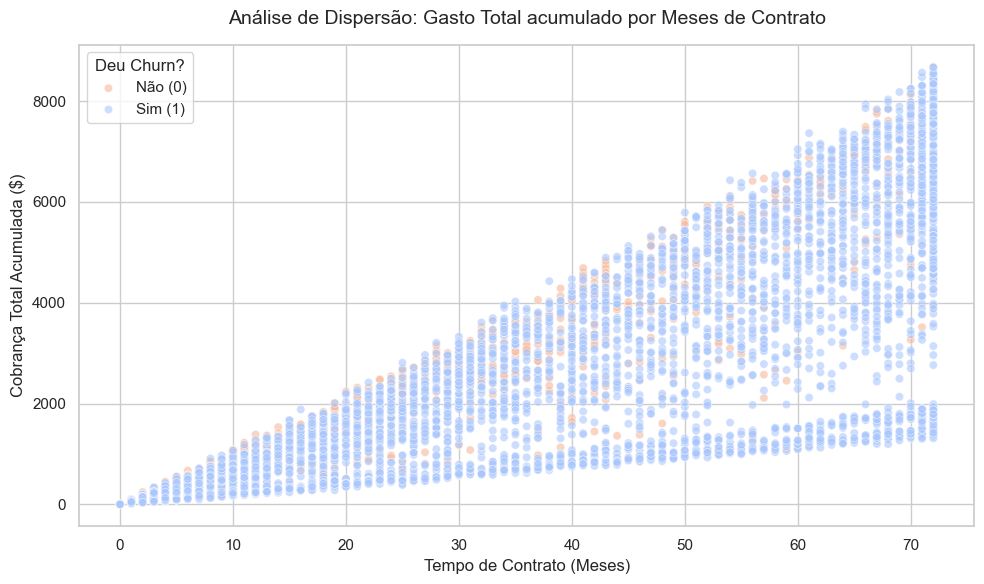

In [980]:
df_base = df_copy.copy()

# Configurando o estilo visual para um padrão corporativo/acadêmico limpo
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Criando o gráfico de dispersão cruzando Gasto Total com Meses de Contrato
# Usamos o 'hue' para mapear as cores de acordo com quem deu Churn ou não
sns.scatterplot(
    data=df_base, 
    x='tenure_months', 
    y='total_charges', 
    hue='churn_value', 
    palette='coolwarm', 
    alpha=0.6
)

plt.title('Análise de Dispersão: Gasto Total acumulado por Meses de Contrato', fontsize=14, pad=15)
plt.xlabel('Tempo de Contrato (Meses)', fontsize=12)
plt.ylabel('Cobrança Total Acumulada ($)', fontsize=12)
plt.legend(title='Deu Churn?', labels=['Não (0)', 'Sim (1)'])

plt.tight_layout()
plt.show()

## Análise de Distribuições

Objetivo: Entender a distribuição das variáveis numéricas e identificar assimetrias

=== ANÁLISE DE ASSIMETRIA (SKEWNESS) E CURTOSE ===

         Coluna  Skewness  Kurtosis         Interpretação
  tenure_months     0.240    -1.387                Normal
monthly_charges    -0.221    -1.257                Normal
  total_charges     0.963    -0.229 Assimétrica à direita
           cltv    -0.312    -0.934                Normal


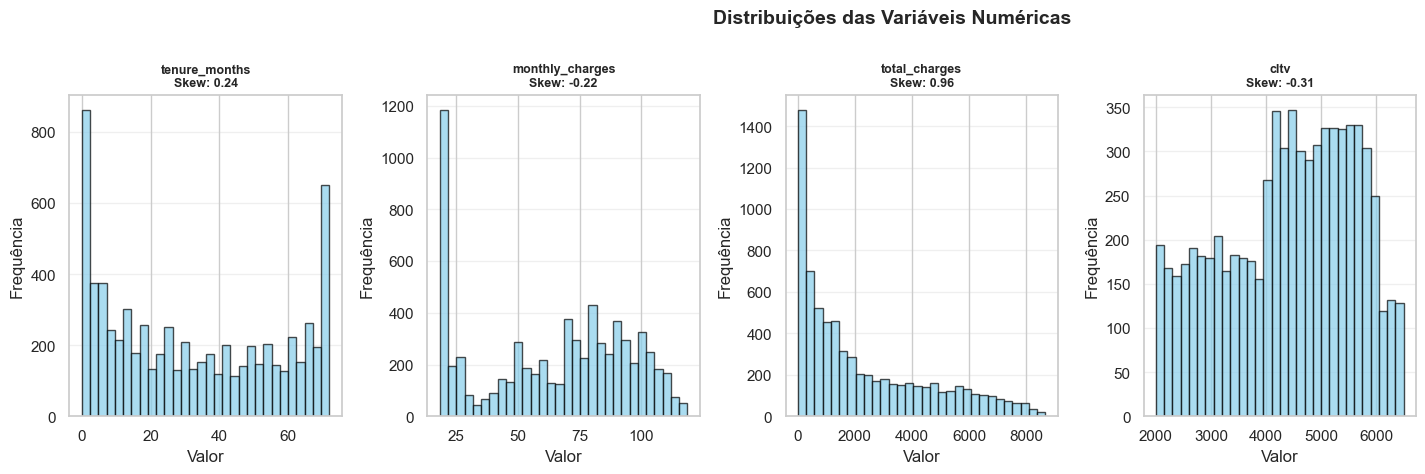

In [981]:
# Análise de distribuições
df_base = df_copy.copy()

print("=== ANÁLISE DE ASSIMETRIA (SKEWNESS) E CURTOSE ===\n")

distribution_stats = []
for col in numeric_cols:
    skewness = df_base[col].skew()
    kurtosis = df_base[col].kurtosis()
    distribution_stats.append({
        'Coluna': col,
        'Skewness': round(skewness, 3),
        'Kurtosis': round(kurtosis, 3),
        'Interpretação': 'Normal' if abs(skewness) < 0.5 else ('Assimétrica à direita' if skewness > 0 else 'Assimétrica à esquerda')
    })

dist_df = pd.DataFrame(distribution_stats)
print(dist_df.to_string(index=False))

# Visualizar distribuições
fig, axes = plt.subplots(3, 5, figsize=(18, 12))
axes = axes.ravel()

for idx, col in enumerate(numeric_cols):
    if idx < len(axes):
        axes[idx].hist(df_base[col].dropna(), bins=30, color='skyblue', edgecolor='black', alpha=0.7)
        axes[idx].set_title(f'{col}\nSkew: {df_base[col].skew():.2f}', fontsize=9, fontweight='bold')
        axes[idx].set_xlabel('Valor')
        axes[idx].set_ylabel('Frequência')
        axes[idx].grid(axis='y', alpha=0.3)

# Remover subplots vazios
for idx in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[idx])

plt.suptitle('Distribuições das Variáveis Numéricas', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

## Análise de Correlações

Objetivo: Identificar relações entre variáveis e detectar multicolinearidade

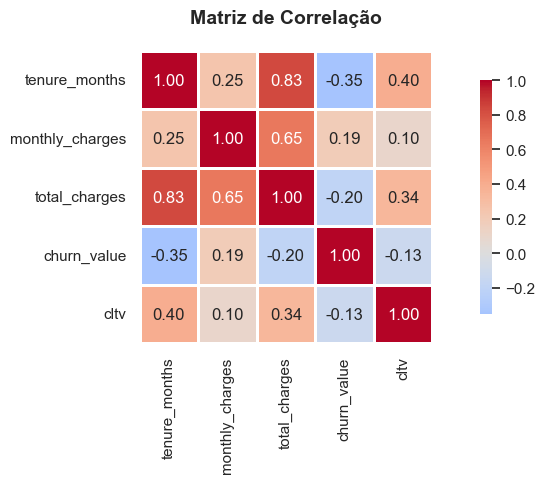

=== CORRELAÇÕES COM A VARIÁVEL TARGET ===

churn_value        1.000000
monthly_charges    0.193356
cltv              -0.127463
total_charges     -0.198324
tenure_months     -0.352229
Name: churn_value, dtype: float64

=== MULTICOLINEARIDADE (Correlação entre features) ===
Pares de features com correlação > 0.7:

    Feature 1     Feature 2  Correlação
tenure_months total_charges       0.826

⚠️ Alta correlação entre features pode causar multicolinearidade!


In [982]:
df_base = df_copy.copy()

# Matriz de correlação apenas para colunas numéricas
corr_numeric = df_base.select_dtypes(include=[np.number]).corr()

# Visualizar matriz de correlação
plt.figure(figsize=(10, 5))
sns.heatmap(corr_numeric, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Matriz de Correlação', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Identificar correlações fortes com o target
print("=== CORRELAÇÕES COM A VARIÁVEL TARGET ===\n")
target_corr = corr_numeric['churn_value'].sort_values(ascending=False)
print(target_corr)

# Identificar pares de features com alta correlação (possível multicolinearidade)
print("\n=== MULTICOLINEARIDADE (Correlação entre features) ===")
print("Pares de features com correlação > 0.7:\n")

high_corr_pairs = []
for i in range(len(corr_numeric.columns)):
    for j in range(i+1, len(corr_numeric.columns)):
        if abs(corr_numeric.iloc[i, j]) > 0.7 and corr_numeric.columns[i] != 'churn_value' and corr_numeric.columns[j] != 'churn_value':
            high_corr_pairs.append({
                'Feature 1': corr_numeric.columns[i],
                'Feature 2': corr_numeric.columns[j],
                'Correlação': round(corr_numeric.iloc[i, j], 3)
            })

if len(high_corr_pairs) > 0:
    high_corr_df = pd.DataFrame(high_corr_pairs).sort_values(by='Correlação', ascending=False)
    print(high_corr_df.to_string(index=False))
    print("\n⚠️ Alta correlação entre features pode causar multicolinearidade!")
else:
    print("✓ Nenhuma correlação forte detectada entre features (excluindo target)")

## Relação da classe City x Churn

In [983]:
df_base = df_copy.copy()

# Agrupa por cidade e calcula a quantidade de clientes e a taxa de churn
analise_cidade = df_base.groupby('city').agg(
    total_clientes=('churn_value', 'count'),
    taxa_churn=('churn_value', 'mean')
).reset_index()

# Transforma a taxa em porcentagem para facilitar a leitura do negócio
analise_cidade['taxa_churn_%'] = (analise_cidade['taxa_churn'] * 100).round(2)

# Filtro de Relevância: Olha apenas cidades com mais de 30 clientes
# (Para evitar que uma cidade com 1 cliente e 1 churn apareça com 100% de taxa)
cidades_relevantes = analise_cidade[analise_cidade['total_clientes'] >= 30]

# 4. Exibe as 10 cidades com MAIOR taxa de Churn
print("=== TOP 10 CIDADES COM MAIOR TAXA DE CHURN ===")
print(cidades_relevantes.sort_values(by='taxa_churn_%', ascending=False).head(10))

=== TOP 10 CIDADES COM MAIOR TAXA DE CHURN ===
              city  total_clientes  taxa_churn  taxa_churn_%
869      San Diego             150    0.333333         33.33
371       Glendale              40    0.325000         32.50
748       Pasadena              30    0.300000         30.00
872  San Francisco             104    0.298077         29.81
562    Los Angeles             305    0.295082         29.51
74        Berkeley              32    0.281250         28.12
972       Stockton              44    0.272727         27.27
878       San Jose             112    0.258929         25.89
354         Fresno              64    0.250000         25.00
556     Long Beach              60    0.250000         25.00


Em vez de jogar a variável fora ou quebrar o modelo com 1.129 colunas, nós vamos aplicar a estratégia de agrupamento inteligente. Vamos mapear apenas as 5 cidades que realmente mostraram um comportamento de alto risco acima da média e colocar todas as outras mais estáveis em um grupo chamado 'Other'.

As 5 cidades críticas que merecem uma coluna própria são: San Diego, Glendale, Pasadena, San Francisco e Los Angeles.

In [984]:
# Definimos a nossa lista de cidades de alto risco com base no seu output
cidades_criticas = ['San Diego', 'Glendale', 'Pasadena', 'San Francisco', 'Los Angeles']

# Criamos uma nova coluna: se a cidade for crítica, mantém o nome. Se não, vira 'Other'
df_base['city_grouped'] = df_base['city'].apply(lambda x: x if x in cidades_criticas else 'Other')

# 3. Validação do novo formato
print("Nova distribuição da variável regional para o modelo:")
print(df_base['city_grouped'].value_counts())

Nova distribuição da variável regional para o modelo:
city_grouped
Other            6414
Los Angeles       305
San Diego         150
San Francisco     104
Glendale           40
Pasadena           30
Name: count, dtype: int64


## Codificação de Variáveis Categóricas (One-hot Encoding)

Algumas variáveis apresentam um comportamento de categorização como No, Yes e No internet service. Desta forma, precisamos aplicar uma tratativa diferente no One-Hot Encoding.

Técnica utilizada: drop='first' no One-Hot Encoding. Se a coluna tem 3 classes (No, Yes, No internet service), o encoder criará apenas 2 colunas: online_security_Yes e online_security_No internet service.
Se ambas forem 0, o modelo deduz matematicamente que o cliente pertence à classe que foi derrubada (No). Isso remove a redundância perfeita e mantém o pipeline matematicamente seguro.

In [985]:
df_base = df_base.copy()

# Isolando as variáveis que possuem essa característica de 3 categorias
colunas_categoricas = [
    'online_security',
    'online_backup',
    'device_protection',
    'tech_support',
    'city_grouped',
    'multiple_lines',
    'streaming_tv',
    'streaming_movies',
    'paperless_billing',
    'internet_service',
    'contract',
    'payment_method']

# Instanciando o Encoder com o drop estratégico para produção
encoder = OneHotEncoder(drop='first', sparse_output=False, dtype=int)

# Aplicando a transformação nas colunas selecionadas
array_encoded = encoder.fit_transform(df_base[colunas_categoricas])

# Recuperando os novos nomes das colunas de forma automática
novos_nomes = encoder.get_feature_names_out(colunas_categoricas)

# Criando o DataFrame com as novas features binarizadas
df_encoded = pd.DataFrame(array_encoded, columns=novos_nomes, index=df_base.index)

# Remove as colunas categóricas antigas
df_base_limpo = df_base.drop(columns=colunas_categoricas)

# Concatena lateralmente (axis=1) a base limpa com as novas colunas dummies/encoded
df_final = pd.concat([df_base_limpo, df_encoded], axis=1)

display(df_final.head())

,country,state,city,gender,senior_citizen,partner,dependents,tenure_months,phone_service,monthly_charges,...,streaming_movies_No internet service,streaming_movies_Yes,paperless_billing_Yes,internet_service_Fiber optic,internet_service_No,contract_One year,contract_Two year,payment_method_Credit card (automatic),payment_method_Electronic check,payment_method_Mailed check
0,United States,California,Los Angeles,Male,No,No,No,2,Yes,53.85,...,0,0,1,0,0,0,0,0,0,1
1,United States,California,Los Angeles,Female,No,No,Yes,2,Yes,70.70,...,0,0,1,1,0,0,0,0,1,0
2,United States,California,Los Angeles,Female,No,No,Yes,8,Yes,99.65,...,0,1,1,1,0,0,0,0,1,0
3,United States,California,Los Angeles,Female,No,Yes,Yes,28,Yes,104.80,...,0,1,1,1,0,0,0,0,1,0
4,United States,California,Los Angeles,Male,No,No,Yes,49,Yes,103.70,...,0,1,1,1,0,0,0,0,0,0


### Analisando classes: country e state

In [986]:
print("\n=== ANÁLISE DE REGIÕES (PAIS) ===\n")
print(df_base['country'].value_counts())

print("\n=== ANÁLISE DE REGIÕES (ESTADOS) ===\n")
print(df_base['state'].value_counts())


=== ANÁLISE DE REGIÕES (PAIS) ===

country
United States    7043
Name: count, dtype: int64

=== ANÁLISE DE REGIÕES (ESTADOS) ===

state
California    7043
Name: count, dtype: int64


As variáveis country e state são variáveis de variância ZERO, isso quer dizer que nesse momento não terá relevância, pois tem valores únicos. Dessa forma, estaremos removendo.

In [987]:
colunas_para_remover = ['country', 'state', 'city']
df_final = df_final.drop(columns=colunas_para_remover, errors='ignore')

df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 37 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   gender                                  7043 non-null   object 
 1   senior_citizen                          7043 non-null   object 
 2   partner                                 7043 non-null   object 
 3   dependents                              7043 non-null   object 
 4   tenure_months                           7043 non-null   int64  
 5   phone_service                           7043 non-null   object 
 6   monthly_charges                         7043 non-null   float64
 7   total_charges                           7043 non-null   float64
 8   churn_value                             7043 non-null   int64  
 9   cltv                                    7043 non-null   int64  
 10  online_security_No internet service     7043 non-null   int6

## Transformando classes Yes e No em 0 e 1

In [988]:
colunas_binarias = ['partner', 'dependents', 'phone_service', 'senior_citizen']

mapeamento = {'Yes': 1, 'No': 0}

# Aplicamos o mapeamento em bloco nas colunas selecionadas
for col in colunas_binarias:
    # O .map() substitui 'Yes' por 1 e 'No' por 0 de forma cirúrgica
    df_final[col] = df_final[col].map(mapeamento)

# Validação do pipeline: Vamos checar se a conversão funcionou e os tipos viraram int
print("Verificação dos novos valores binarizados:")
display(df_final[colunas_binarias].head())
print("\nTipos atuais das colunas:")
print(df_final[colunas_binarias].dtypes)

Verificação dos novos valores binarizados:


,partner,dependents,phone_service,senior_citizen
0,0,0,1,0
1,0,1,1,0
2,0,1,1,0
3,1,1,1,0
4,0,1,1,0



Tipos atuais das colunas:
partner           int64
dependents        int64
phone_service     int64
senior_citizen    int64
dtype: object


In [989]:
mapeamento_genero = {'Female': 1, 'Male': 0}

df_final['gender'] = df_final['gender'].map(mapeamento_genero)

# 3. Boa prática de MLOps: Renomeamos a coluna para deixar explícito quem é o '1'
df_final = df_final.rename(columns={'gender': 'is_female'})

# 4. Validação final do pipeline
print("Verificação da binarização de gênero:")
print(df_final['is_female'].value_counts())

Verificação da binarização de gênero:
is_female
0    3555
1    3488
Name: count, dtype: int64


## Normalizar classes: tenure_months e monthly_charges com MinMaxScaler

In [990]:
# Definimos as colunas numéricas que realmente ficaram na base
colunas_numericas = ['tenure_months', 'monthly_charges', 'total_charges', 'cltv']

# Instanciamos o Scaler
scaler = MinMaxScaler()

# Aplicamos a transformação apenas nas colunas numéricas
df_final[colunas_numericas] = scaler.fit_transform(df_final[colunas_numericas])

In [991]:
df_final.info()

df_final.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 37 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   is_female                               7043 non-null   int64  
 1   senior_citizen                          7043 non-null   int64  
 2   partner                                 7043 non-null   int64  
 3   dependents                              7043 non-null   int64  
 4   tenure_months                           7043 non-null   float64
 5   phone_service                           7043 non-null   int64  
 6   monthly_charges                         7043 non-null   float64
 7   total_charges                           7043 non-null   float64
 8   churn_value                             7043 non-null   int64  
 9   cltv                                    7043 non-null   float64
 10  online_security_No internet service     7043 non-null   int6

,is_female,senior_citizen,partner,dependents,tenure_months,phone_service,monthly_charges,total_charges,churn_value,cltv,...,streaming_movies_No internet service,streaming_movies_Yes,paperless_billing_Yes,internet_service_Fiber optic,internet_service_No,contract_One year,contract_Two year,payment_method_Credit card (automatic),payment_method_Electronic check,payment_method_Mailed check
0,0,0,0,0,0.027778,1,0.354229,0.012453,1,0.274850,...,0,0,1,0,0,0,0,0,0,1
1,1,0,0,1,0.027778,1,0.521891,0.017462,1,0.155215,...,0,0,1,1,0,0,0,0,1,0
2,1,0,0,1,0.111111,1,0.809950,0.094475,1,0.749166,...,0,1,1,1,0,0,0,0,1,0
3,1,0,1,1,0.388889,1,0.861194,0.350733,1,0.667111,...,0,1,1,1,0,0,0,0,1,0
4,0,0,0,1,0.680556,1,0.850249,0.579898,1,0.742050,...,0,1,1,1,0,0,0,0,0,0


# Experimentação e MVP (Minimum Viable Product)
## Regressão Logística (Baseline)

### Separando dados de treino e teste com train_test_split

In [992]:
df_modelo = df_final.copy()

x = df_modelo.drop(columns=["churn_value"])
y = df_modelo["churn_value"]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

### Treinando modelo com dados desbalanceados

In [993]:
modelo = LogisticRegression(random_state=42)
modelo.fit(x_train, y_train)

y_pred = modelo.predict(x_test)

print("=== RELATÓRIO DE CLASSIFICAÇÃO ===\n")
print(classification_report(y_test, y_pred))

=== RELATÓRIO DE CLASSIFICAÇÃO ===

              precision    recall  f1-score   support

           0       0.84      0.89      0.87      1009
           1       0.68      0.58      0.63       400

    accuracy                           0.80      1409
   macro avg       0.76      0.74      0.75      1409
weighted avg       0.80      0.80      0.80      1409



### Separando dados com KFold e Validação Cruzada

In [994]:
# test_score é o resultado do modelo
def intervalo_conf(resultados):
    media = resultados['test_score'].mean()
    desvio_padrao = resultados['test_score'].std()
    print(f'Intervalo de confiança: [{media - 2*desvio_padrao}, {min(media + 2*desvio_padrao, 1)}]')

In [995]:
modelo = LogisticRegression(random_state=42)
kf = KFold(n_splits = 5, shuffle = True, random_state = 42)
cv_resultados = cross_validate(modelo, x, y, cv = kf, scoring = 'recall')
intervalo_conf(cv_resultados)

Intervalo de confiança: [0.5315029810346804, 0.6291276883095752]


## Estratificando os dados

- No processo de aleatorização do kfold, é dificil ele manter a proporção dos dados, pois estãod desbalanceados

In [996]:
df_modelo = df_final.copy()

df_modelo['churn_value'].value_counts(normalize=True)

churn_value
0    0.73463
1    0.26537
Name: proportion, dtype: float64

In [997]:
from sklearn.model_selection import StratifiedKFold

modelo = LogisticRegression(random_state=42)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_resultados_stratified = cross_validate(modelo, x, y, cv=skf, scoring='recall')
intervalo_conf(cv_resultados_stratified)

Intervalo de confiança: [0.5365650271836235, 0.6180822180171621]


## Balanceamento de dados

Vamos comparar duas estratégias: oversamplig e undersampling

### Oversampling com SMOTE

In [998]:
# Vai criar novas amostras sintéticas da classe minoritária (churn = 1) para balancear o dataset
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
x_balanceado, y_balanceamento = smote.fit_resample(x, y)

print("Distribuição original da variável target:")
print(y.value_counts(normalize=True))

print("\nDistribuição após SMOTE:")
print(y_balanceamento.value_counts(normalize=True))

Distribuição original da variável target:
churn_value
0    0.73463
1    0.26537
Name: proportion, dtype: float64

Distribuição após SMOTE:
churn_value
1    0.5
0    0.5
Name: proportion, dtype: float64


In [999]:
modelo = LogisticRegression(random_state=42)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_resultados_stratified = cross_validate(modelo, x, y, cv=skf, scoring='recall')
intervalo_conf(cv_resultados_stratified)

Intervalo de confiança: [0.5365650271836235, 0.6180822180171621]


O resultado RECALL do modelo melhorou, porém, a analise deveria ser feita em cima dos dados desbalanceados 

### Pipeline com Imblearn

Para analisar os dados desbalanceados, nesse processo valos utilizar a lib imblearn, pois o método de estratificação foi feito com ela.

In [1000]:
from imblearn.pipeline import Pipeline as imbpipeline

modelo = LogisticRegression(random_state=42)
pipeline = imbpipeline([
    ('oversample', SMOTE(random_state=42)),
    ('rl', modelo)])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_resultados_stratified = cross_validate(pipeline, x, y, cv=skf, scoring='recall')
intervalo_conf(cv_resultados_stratified)


Intervalo de confiança: [0.7264189636919027, 0.8027490769096657]


### Aplicando o Undersampling

- Vamos reduzir a quantidade de dados da classe que tem maior quantidade de dados
- Vamos aplicar o near miss, o modelo não vai reduzir de forma aleatoria, ele utiliza um critério para remover

In [1001]:
from imblearn.under_sampling import NearMiss

modelo = LogisticRegression(random_state=42)
pipeline = imbpipeline([
    ('undersample', NearMiss(version=1)),
    ('rl', modelo)])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_resultados_stratified = cross_validate(pipeline, x, y, cv=skf, scoring='recall')
intervalo_conf(cv_resultados_stratified)

Intervalo de confiança: [0.7482905128195811, 0.8076355670932516]


## Testando o Modelo

              precision    recall  f1-score   support

           0       0.88      0.68      0.77      1009
           1       0.49      0.77      0.60       400

    accuracy                           0.70      1409
   macro avg       0.68      0.73      0.68      1409
weighted avg       0.77      0.70      0.72      1409



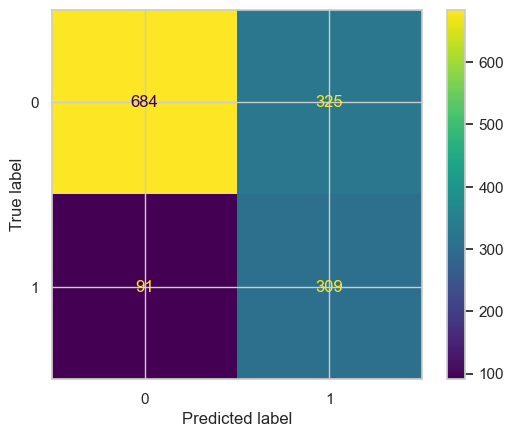

In [1002]:
from sklearn.metrics import ConfusionMatrixDisplay

undersampler = NearMiss(version=1)
x_balanceado, y_balanceamento = undersampler.fit_resample(x, y)

modelo = LogisticRegression(random_state=42)
modelo.fit(x_balanceado, y_balanceamento)

y_pred = modelo.predict(x_test)

print(classification_report(y_test, y_pred))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

              precision    recall  f1-score   support

           0       0.89      0.76      0.82      1009
           1       0.56      0.77      0.65       400

    accuracy                           0.76      1409
   macro avg       0.73      0.76      0.73      1409
weighted avg       0.80      0.76      0.77      1409



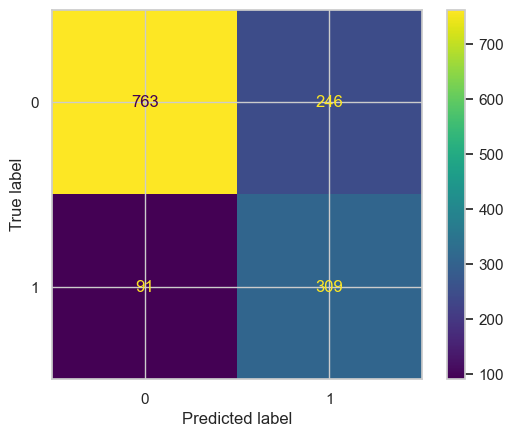

In [1003]:
from sklearn.metrics import ConfusionMatrixDisplay

oversampling = SMOTE(random_state=42)
x_balanceado, y_balanceamento = oversampling.fit_resample(x, y)

modelo = LogisticRegression(random_state=42)
modelo.fit(x_balanceado, y_balanceamento)

y_pred = modelo.predict(x_test)

print(classification_report(y_test, y_pred))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)